### [Advanced Python Visualization Techniques for Data Scientists](https://python.plainenglish.io/stop-using-basic-bar-charts-7advanced-python-visualization-techniques-for-data-scientists-8d0c31d30c0c)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import networkx as nx

from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Data (Directly from source or local file)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
print("Loading dataset... this may take a moment.")
df = pd.read_excel(url)

# Basic Data Cleaning
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalCost'] = df['Quantity'] * df['UnitPrice']

print(f"Data ready: {df.shape[0]} rows loaded.")

Loading dataset... this may take a moment.
Data ready: 397884 rows loaded.


#### **Pareto Chart (Dual Axis)**

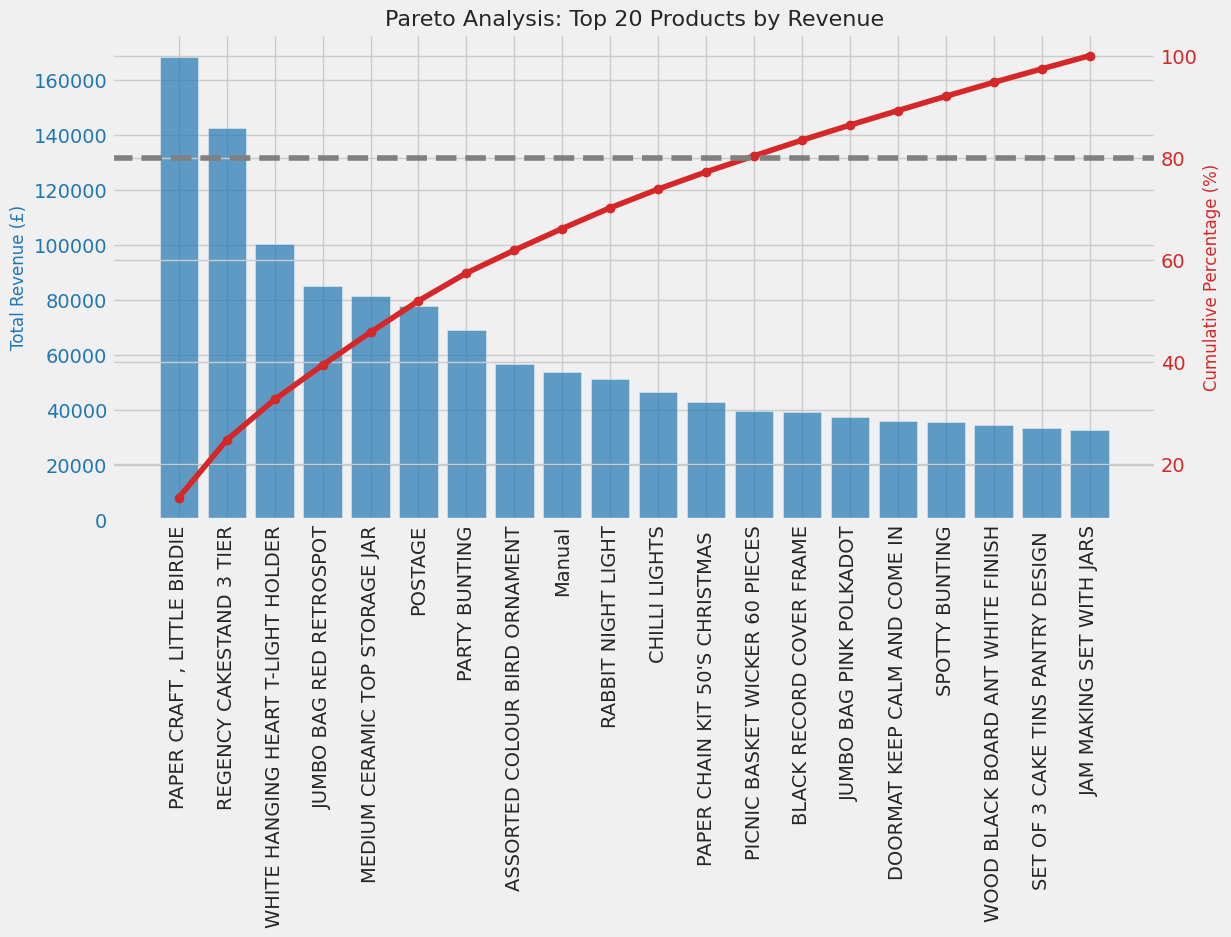

In [3]:
# Aggregate data
product_sales = df.groupby('Description')['TotalCost'].sum().sort_values(ascending=False).head(20)
cumulative_pct = product_sales.cumsum() / product_sales.sum() * 100

# Create Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart
ax1.bar(product_sales.index, product_sales.values, color='tab:blue', alpha=0.7)
ax1.set_ylabel('Total Revenue (£)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticklabels(product_sales.index, rotation=90)

# Dual Axis for Line Chart
ax2 = ax1.twinx()
ax2.plot(product_sales.index, cumulative_pct.values, color='tab:red', marker='o', linestyle='-')
ax2.set_ylabel('Cumulative Percentage (%)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.axhline(80, color='grey', linestyle='--') # 80% threshold

plt.title('Pareto Analysis: Top 20 Products by Revenue', fontsize=16)
plt.show()

#### **Hexbin Plot (Managing Overplotting)**

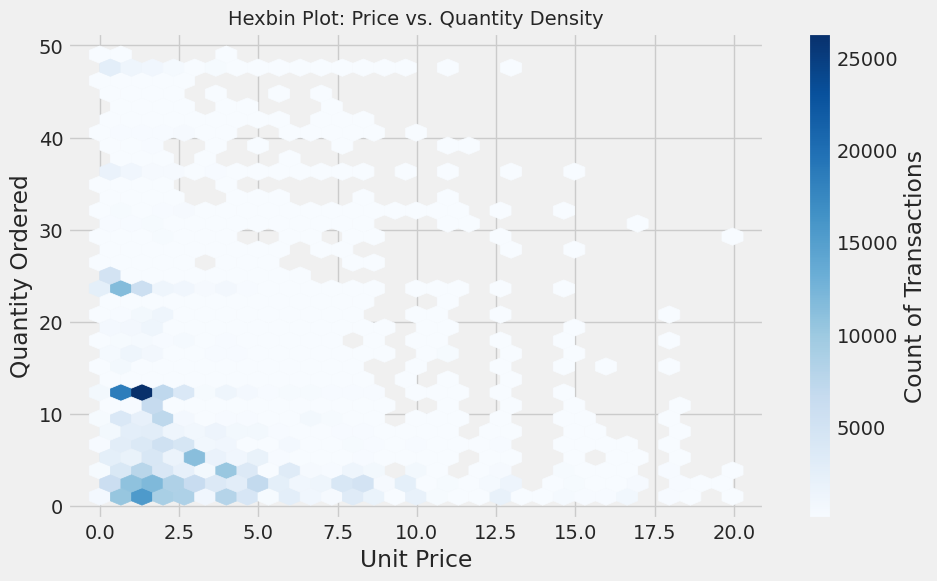

In [4]:
# Filter outliers for better visualization
sub_df = df[(df['Quantity'] < 50) & (df['UnitPrice'] < 20)]

plt.figure(figsize=(10, 6))
plt.hexbin(sub_df['UnitPrice'], sub_df['Quantity'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(label='Count of Transactions')
plt.xlabel('Unit Price')
plt.ylabel('Quantity Ordered')
plt.title('Hexbin Plot: Price vs. Quantity Density', fontsize=14)
plt.show()

#### **Violin Plot**

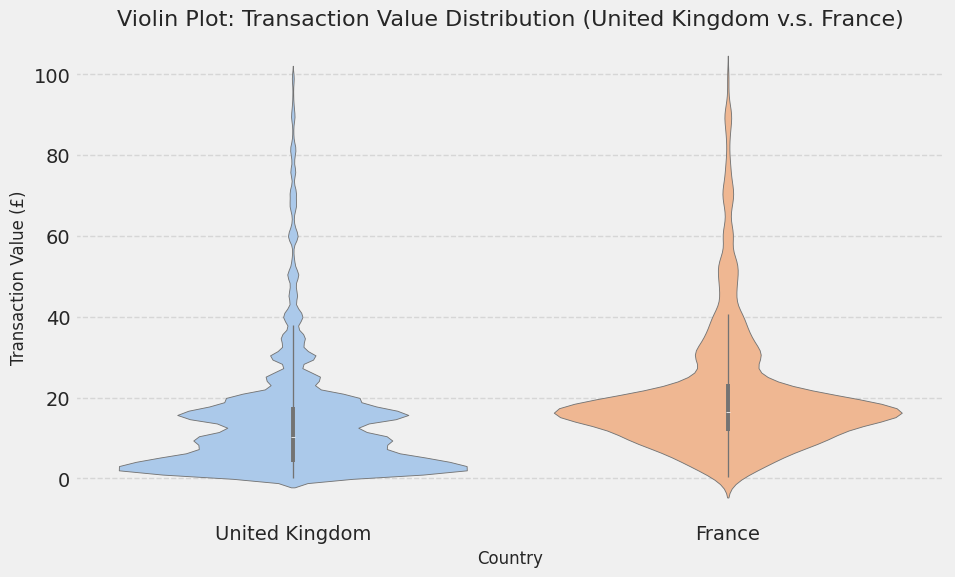

In [5]:
# Filter for France and UK, and remove extreme outliers for better visualization
france_germany_df = df[df['Country'].isin(['France', 'United Kingdom']) & (df['TotalCost'] < 100)]

plt.figure(figsize=(10, 6))
sns.violinplot(x='Country', y='TotalCost', data=france_germany_df, palette='pastel')
plt.title('Violin Plot: Transaction Value Distribution (United Kingdom v.s. France)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Transaction Value (£)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Interactive Choropleth Map**

In [6]:
country_sales = df.groupby('Country')['TotalCost'].sum().reset_index()

fig = px.choropleth(country_sales,
                    locations="Country",
                    locationmode='country names',
                    color="TotalCost",
                    hover_name="Country",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Global Revenue Distribution (Interactive)")
fig.show()

#### **Cohort Analysis Heatmap**

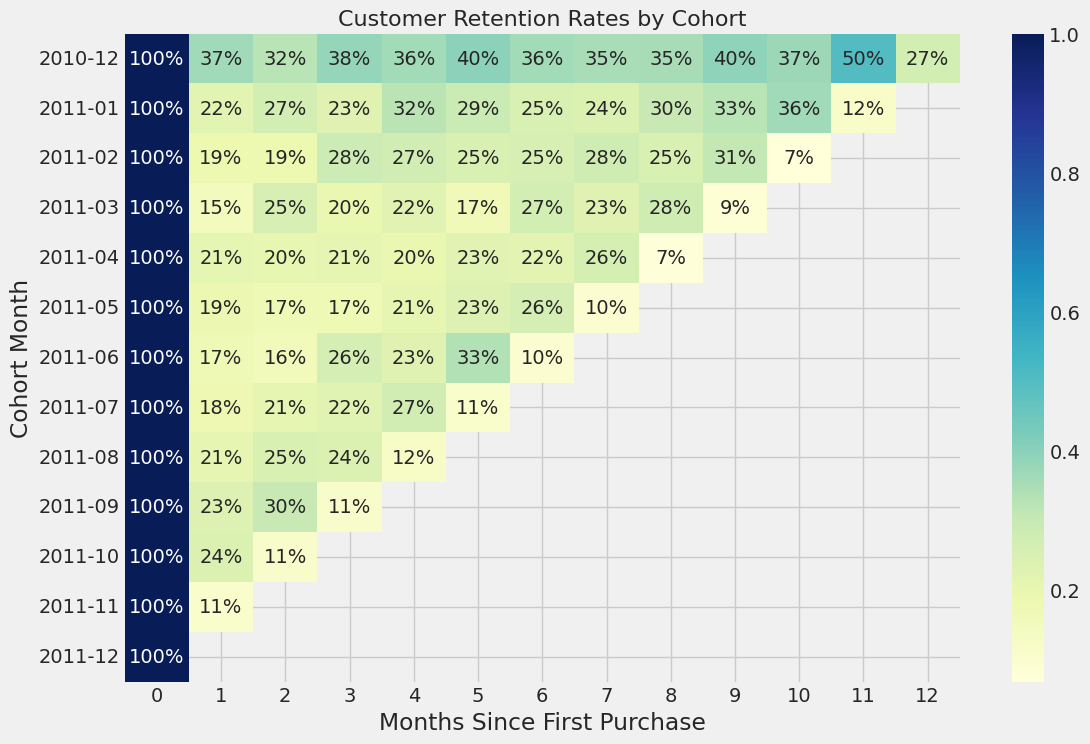

In [7]:
# 1. Create Cohort Month
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Cohort'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# 2. Aggregate
cohort_data = df.groupby(['Cohort', 'OrderMonth']).agg(n_customers=('CustomerID', 'nunique')).reset_index()
cohort_data['Period'] = (cohort_data.OrderMonth - cohort_data.Cohort).apply(lambda x: x.n)

# 3. Pivot
cohort_pivot = cohort_data.pivot_table(index = 'Cohort', columns = 'Period', values = 'n_customers')
cohort_size = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_size, axis = 0)

# 4. Plot
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Customer Retention Rates by Cohort', fontsize=16)
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

#### **Month vs. Day Heatmap**

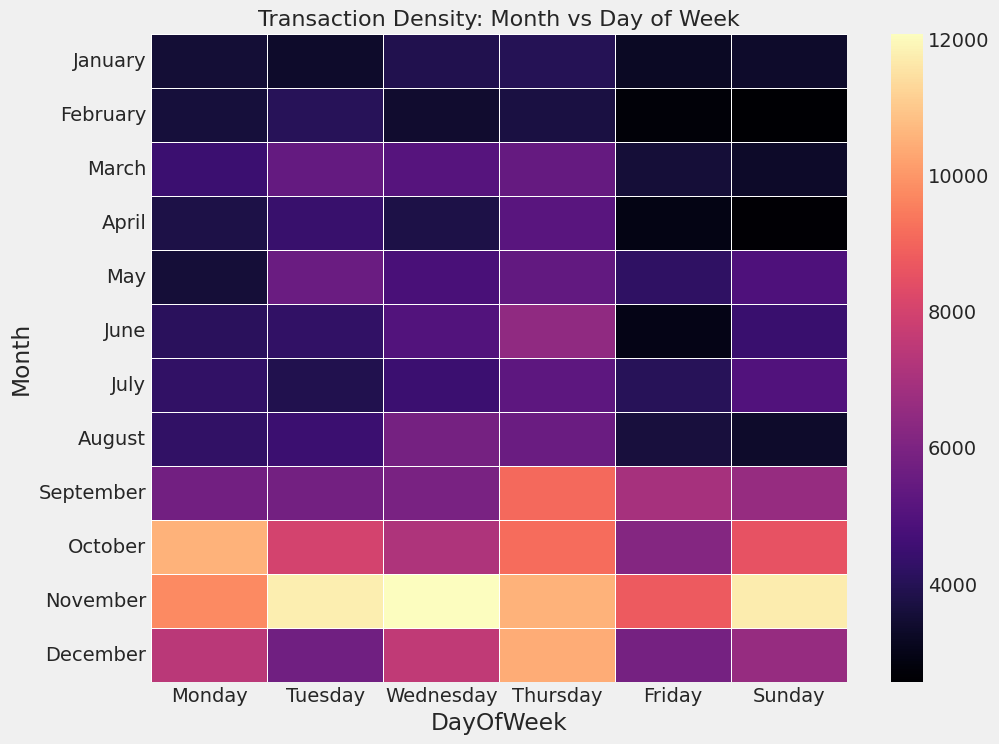

In [8]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Month'] = df['InvoiceDate'].dt.month_name()

# Order for plotting
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

pivot_activity = df.pivot_table(index='Month', columns='DayOfWeek', values='InvoiceNo', aggfunc='count').reindex(months)
pivot_activity = pivot_activity[days]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_activity, cmap='magma', annot=False, linewidths=.5)
plt.title('Transaction Density: Month vs Day of Week', fontsize=16)
plt.show()

#### **Time Series**

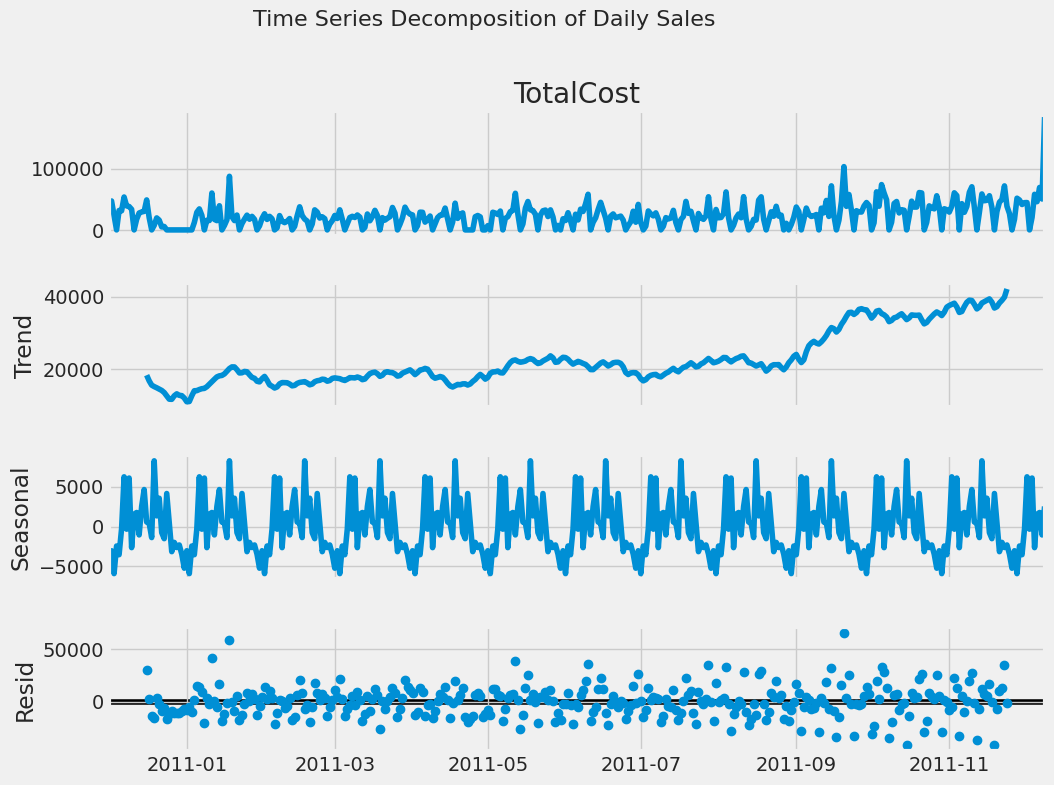

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to daily sales
daily_sales = df.set_index('InvoiceDate').resample('D')['TotalCost'].sum().fillna(0)

# Decompose
decomposition = seasonal_decompose(daily_sales, model='additive', period=30)

# Plot
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Daily Sales', y=1.02, fontsize=16)
plt.show()